In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (matthews_corrcoef, confusion_matrix,
                             accuracy_score, precision_score, recall_score)
import pickle
from Bio.SeqUtils.ProtParam import ProteinAnalysis, ProtParamData
import statistics as st

os.makedirs("model_evaluation", exist_ok=True)


## Import dataset

In [2]:
dataset = pd.read_csv("../2.Data_Preparation/train_bench.tsv", sep="\t")


## Helper functions

In [3]:
def get_scale_features(seq, scale, window, output_type):
    """Return max or mean of a residue scale over a sliding window."""
    sequence = ProteinAnalysis(seq)
    w = window if len(seq) >= window else len(seq)
    if isinstance(scale, dict):
        scale_result = sequence.protein_scale(scale, w, edge=1)
    else:
        param_dict   = getattr(ProtParamData, scale)
        scale_result = sequence.protein_scale(param_dict, w, edge=1)
    return st.mean(scale_result) if output_type == "mean" else max(scale_result)


def scale_function(df, val_dict, output_type):
    value_list = []
    for seq in df:
        seq = seq.replace("X", "").replace("U", "C")
        value_list.append(get_scale_features(seq, val_dict, 15, output_type))
    return value_list


# Von Heijne Performance

In [4]:
import sys
from importnb import Notebook

sys.path.append("../4.vonHeijne/")
with Notebook():
    import create_pswm, validation_and_testing_vonheijne


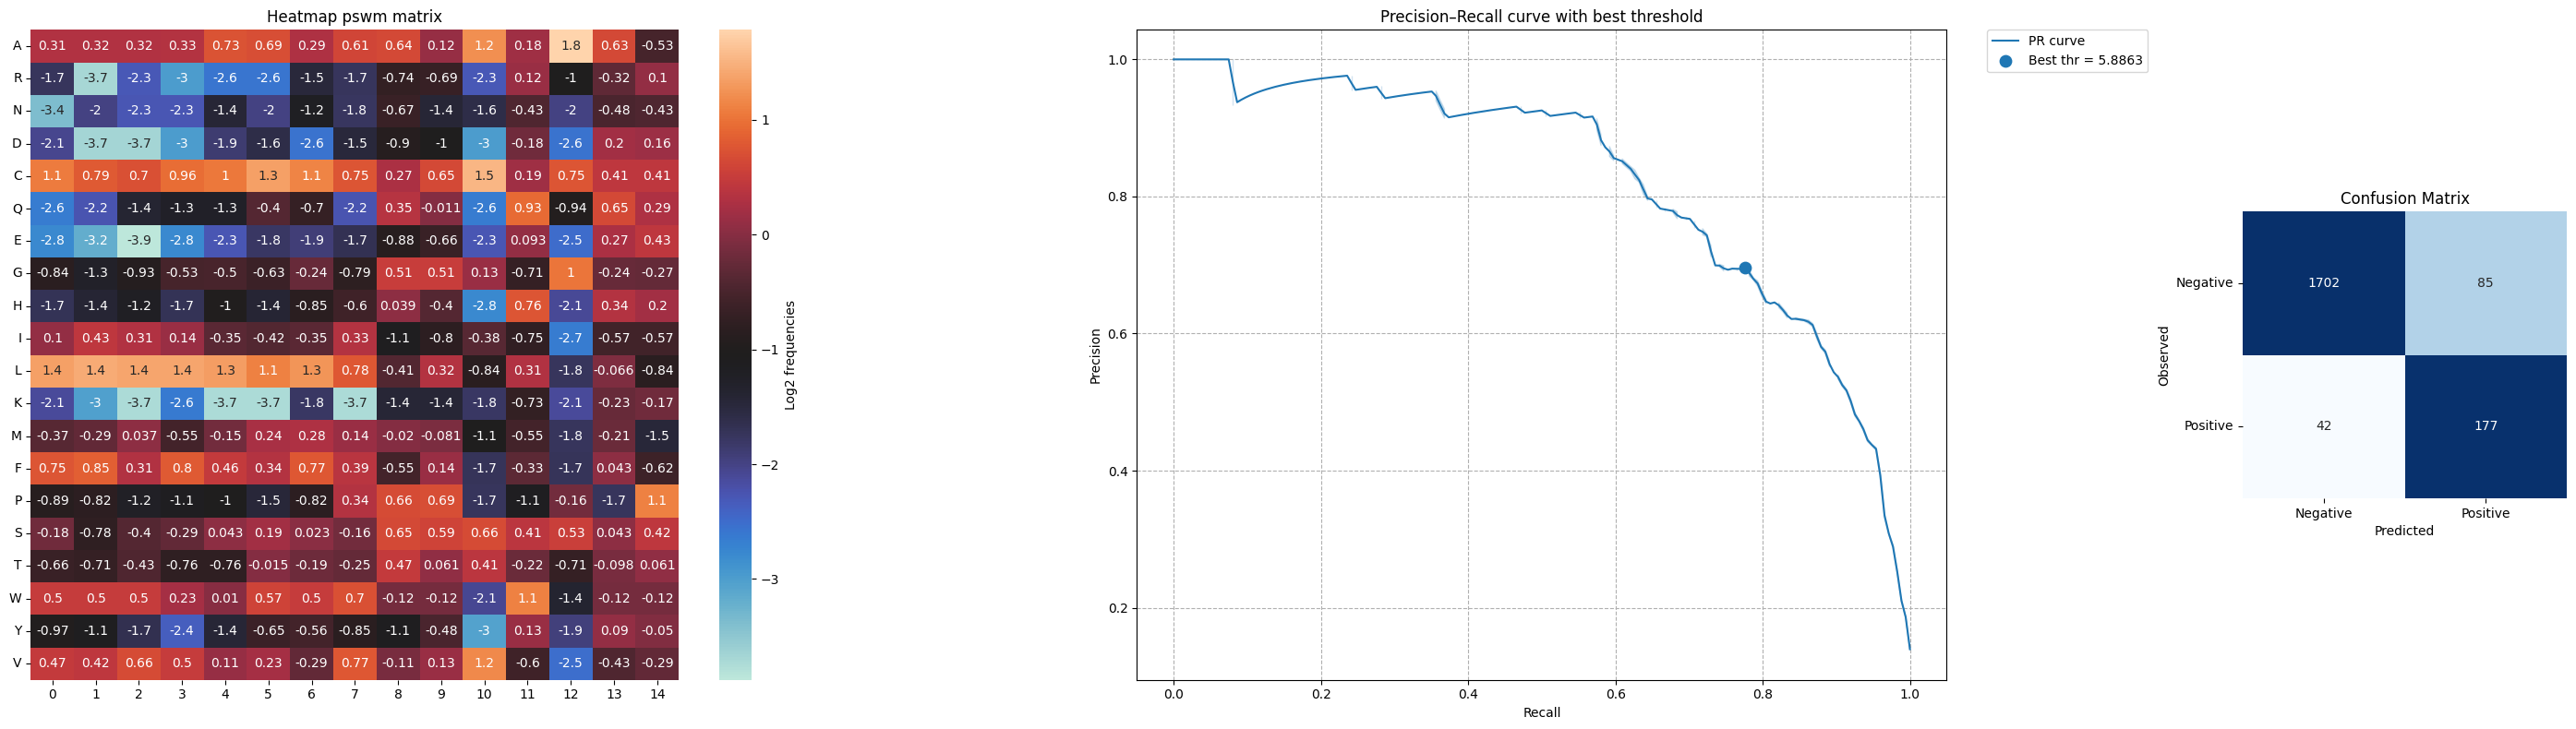

In [5]:
pswm  = create_pswm.get_pswm(
    dataset.query("(Set=='1' or Set=='5' or Set=='3' or Set=='4') and Class=='Positive'"),
    13, 2)
stats = validation_and_testing_vonheijne.metrics(
    pswm,
    dataset.query("Set=='2'"),
    dataset.query("Set=='Benchmark'"))


In [6]:
metrics_name = ["MCC", "Precision", "Accuracy", "Sensitivity", "Confusion Matrix"]
for name, stat in zip(metrics_name, stats):
    if name == "Confusion Matrix":
        confusion_df = pd.DataFrame(stat,
                                    columns=["Negative", "Positive"],
                                    index=["Negative", "Positive"])
        print(f"{name}:\n{confusion_df}")
    else:
        print(f"{name} = {stat}")


MCC = 0.7039588498678732
Precision = 0.9366899302093719
Accuracy = 0.6755725190839694
Sensitivity = 0.8082191780821918
Confusion Matrix:
          Negative  Positive
Negative      1702        85
Positive        42       177


# SVM Performance

In [7]:
with open('SignalPeptideSVM.pkl', 'rb') as f:
    final_classifier = pickle.load(f)

loaded_data_test = np.load('benchmark_features.npz')
x_test = loaded_data_test['matrix']
y_test = loaded_data_test['target']

bench_pred = final_classifier.predict(x_test)


SVM Metrics:
MCC = 0.7206409034836112
Precision = 0.8430232558139535
Sensitivity = 0.6621004566210046
Accuracy = 0.9496510468594217


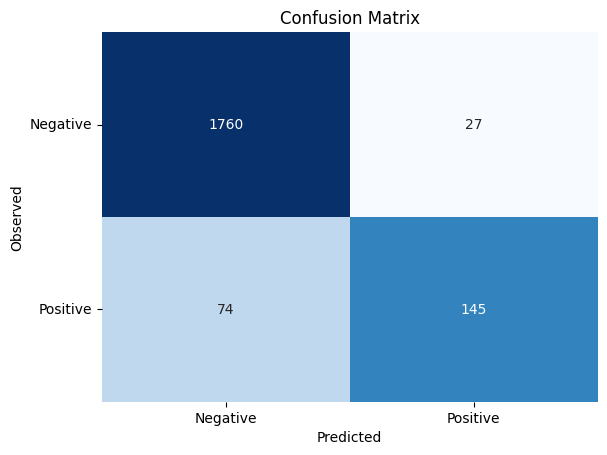

In [8]:
conf_mat        = confusion_matrix(y_test, bench_pred)
svm_mcc         = matthews_corrcoef(y_test, bench_pred)
svm_precision   = precision_score(y_test, bench_pred)
svm_sensitivity = recall_score(y_test, bench_pred)
svm_accuracy    = accuracy_score(y_test, bench_pred)
print(f"SVM Metrics:\nMCC = {svm_mcc}\nPrecision = {svm_precision}\n"
      f"Sensitivity = {svm_sensitivity}\nAccuracy = {svm_accuracy}")

sns.heatmap(conf_mat, annot=True, cmap="Blues", fmt="d", cbar=False, vmax=200)
plt.xlabel("Predicted"); plt.ylabel("Observed"); plt.title("Confusion Matrix")
plt.xticks(ticks=[0.5, 1.5], labels=["Negative", "Positive"])
plt.yticks(ticks=[0.5, 1.5], labels=["Negative", "Positive"], rotation=0)
plt.show()


In [9]:
# Build FP / FN index lists
svm_fp, svm_fn = [], []
for i in range(len(y_test)):
    if bench_pred[i] == 0 and y_test[i] == 1:
        svm_fn.append(i)
    elif bench_pred[i] == 1 and y_test[i] == 0:
        svm_fp.append(i)


In [10]:
benchmark            = dataset.query("Set=='Benchmark'")
false_positives_df   = benchmark.iloc[svm_fp]
false_negatives_df   = benchmark.iloc[svm_fn]
true_positives_df    = benchmark.query("Class == 'Positive'")
true_negatives_df    = benchmark.query("Class == 'Negative'")

classification_col = []
for i in range(benchmark.shape[0]):
    if i in svm_fp:
        classification_col.append("FP")
    elif i in svm_fn:
        classification_col.append("FN")
    elif benchmark.iloc[i]["Class"] == "Negative":
        classification_col.append("TN")
    else:
        classification_col.append("TP")

prediction_dataset = benchmark.copy()
prediction_dataset["Prediction"] = classification_col
prediction_dataset.to_csv('benchmark_predictions.tsv', sep='\t', index=False)


In [11]:
print(prediction_dataset.shape, benchmark.shape)
print("FP count:", prediction_dataset.query("Prediction == 'FP'").shape[0])
print("FN count:", prediction_dataset.query("Prediction == 'FN'").shape[0])


(2006, 11) (2006, 10)
FP count: 27
FN count: 74


## Plotting

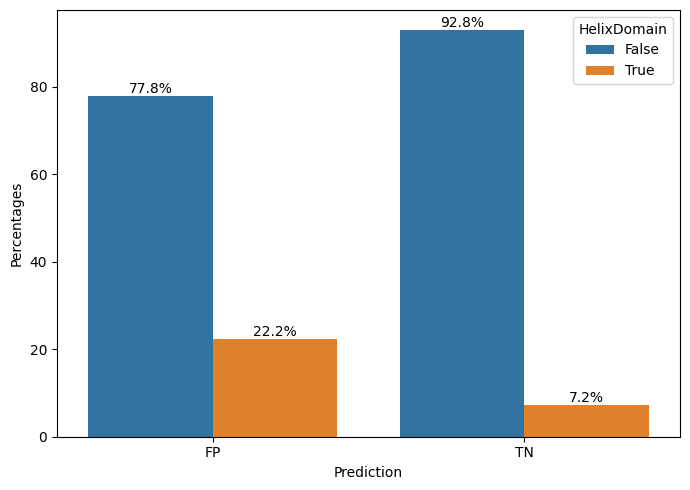

In [12]:
counts = (prediction_dataset.groupby(["Prediction", "HelixDomain"])
          .size().rename("n").reset_index())
counts["percent"] = counts.groupby("Prediction")["n"].transform(
    lambda s: (s / s.sum()) * 100)

plt.figure(figsize=(7, 5))
ax = sns.barplot(data=counts, x="Prediction", y="percent", hue="HelixDomain")
ax.set_ylabel("Percentages"); ax.set_xlabel("Prediction")
ax.legend(title="HelixDomain")
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%")
plt.tight_layout()
plt.savefig("model_evaluation/HelixDomain_predictions.png", dpi=300)
plt.show()


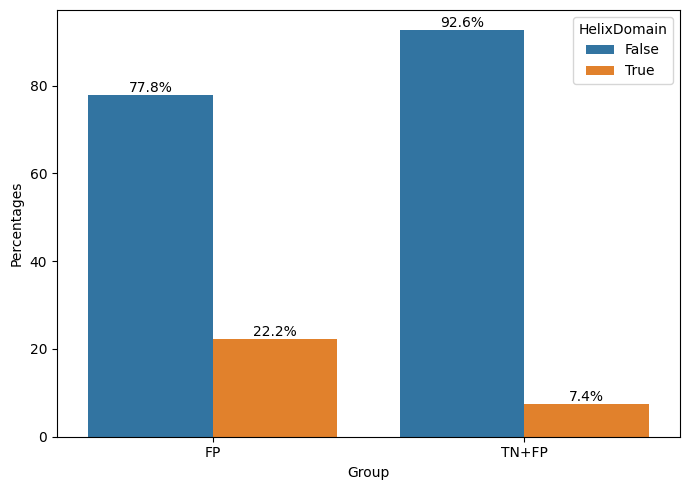

In [13]:
all_negatives = prediction_dataset.query("Class=='Negative'").copy()
all_negatives['Group'] = "TN+FP"
false_positive = prediction_dataset.query("Prediction=='FP'").copy()
false_positive['Group'] = "FP"
counts_group = pd.concat([false_positive, all_negatives], ignore_index=True)

counts = (counts_group.groupby(["Group", "HelixDomain"])
          .size().rename("n").reset_index())
counts["percent"] = counts.groupby("Group")["n"].transform(
    lambda s: (s / s.sum()) * 100)

plt.figure(figsize=(7, 5))
ax = sns.barplot(data=counts, x="Group", y="percent", hue="HelixDomain")
ax.set_ylabel("Percentages"); ax.set_xlabel("Group")
ax.legend(title="HelixDomain")
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%")
plt.tight_layout()
plt.savefig("model_evaluation/HD_prediction_2.png", dpi=300)
plt.show()


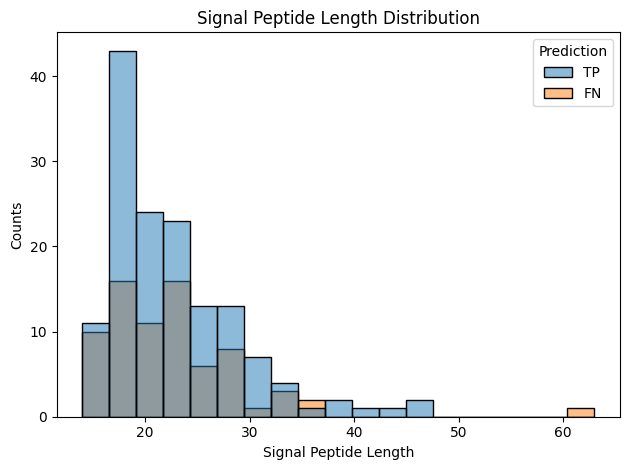

In [14]:
# FIX 1: sp_length must be derived from length_df, not from the full
# prediction_dataset — using prediction_dataset caused index-mismatch NaNs.
length_df = prediction_dataset.query("Class == 'Positive'").copy()
length_df["sp_length"] = length_df["SPEnd"] - length_df["SPStart"]  # fixed

sns.histplot(data=length_df, x="sp_length", hue="Prediction")
plt.title("Signal Peptide Length Distribution")
plt.ylabel("Counts"); plt.xlabel("Signal Peptide Length")
plt.tight_layout()
plt.savefig("model_evaluation/Signalength_distribution.png", dpi=300)
plt.show()


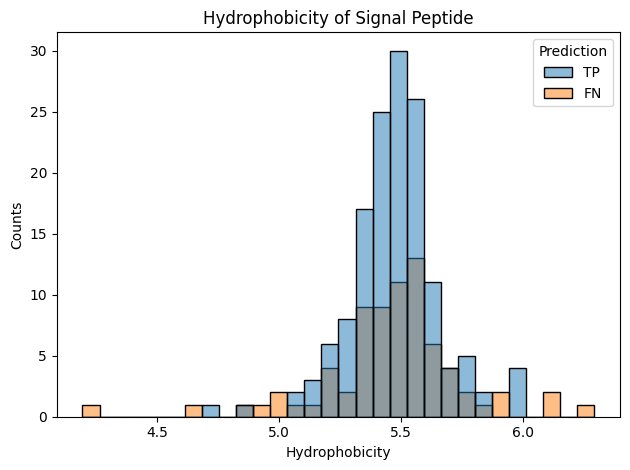

In [15]:
hydro_df = prediction_dataset.query("Class == 'Positive'").copy()
hydro_df["hydrophobicity"] = hydro_df.apply(
    lambda row: get_scale_features(
        row["Sequence"], "mi", int(row["SPEnd"] - row["SPStart"]), "mean"),
    axis=1)

sns.histplot(data=hydro_df, x="hydrophobicity", hue="Prediction")
plt.title("Hydrophobicity of Signal Peptide")
plt.ylabel("Counts"); plt.xlabel("Hydrophobicity")
plt.tight_layout()
plt.savefig("model_evaluation/Hydrophobicity_distribution.png", dpi=300)
plt.show()


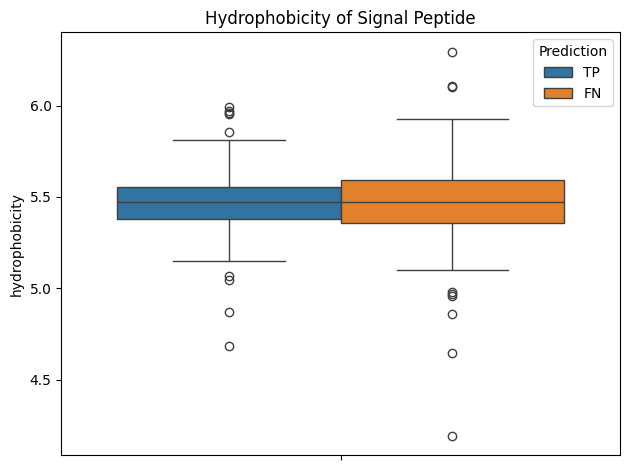

In [16]:
sns.boxplot(data=hydro_df, y="hydrophobicity", hue="Prediction")
plt.title("Hydrophobicity of Signal Peptide")
plt.tight_layout()
plt.savefig("model_evaluation/Boxplot_hydrophobicity.png", dpi=300)
plt.show()


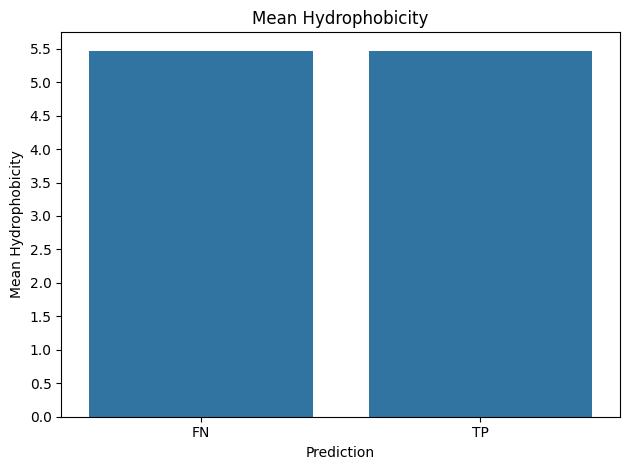


 Prediction
FN    5.460668
TP    5.470469
Name: hydrophobicity, dtype: float64 



In [17]:
hydro_means = hydro_df.groupby('Prediction')['hydrophobicity'].mean()
sns.barplot(x=hydro_means.index, y=hydro_means.values)
plt.ylabel("Mean Hydrophobicity")
plt.yticks([i / 10 for i in range(0, 60, 5)])
plt.title("Mean Hydrophobicity")
plt.tight_layout()
plt.savefig("model_evaluation/Mean_hydrophobicity.png", dpi=300)
plt.show()
print("\n", hydro_means, "\n")


## False Positive Rate Comparison

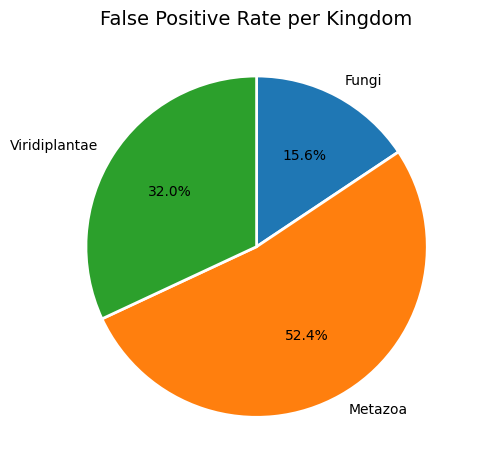

In [18]:
false_positives = prediction_dataset.query("Prediction=='FP'")
counts_falsepositive = (false_positives.groupby(["Kingdom", "Prediction"])
                        .size().rename("n").reset_index())
counts_falsepositive["total"] = counts_falsepositive["Kingdom"].map(
    benchmark.query("Class=='Negative'").groupby(["Kingdom"]).size())
counts_falsepositive["percent"] = counts_falsepositive.groupby("Kingdom")["n"].transform(
    lambda s: (s / counts_falsepositive["total"]) * 100)

fig, ax = plt.subplots()
ax.pie(counts_falsepositive["percent"],
       labels=counts_falsepositive["Kingdom"],
       autopct="%.1f%%", startangle=90, counterclock=False,
       wedgeprops={"linewidth": 2, "edgecolor": "white"})
ax.set_title("False Positive Rate per Kingdom", fontsize=14)
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("model_evaluation/pieplot_kingdom_FPR.png", dpi=300)
plt.show()


/Users/negin/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


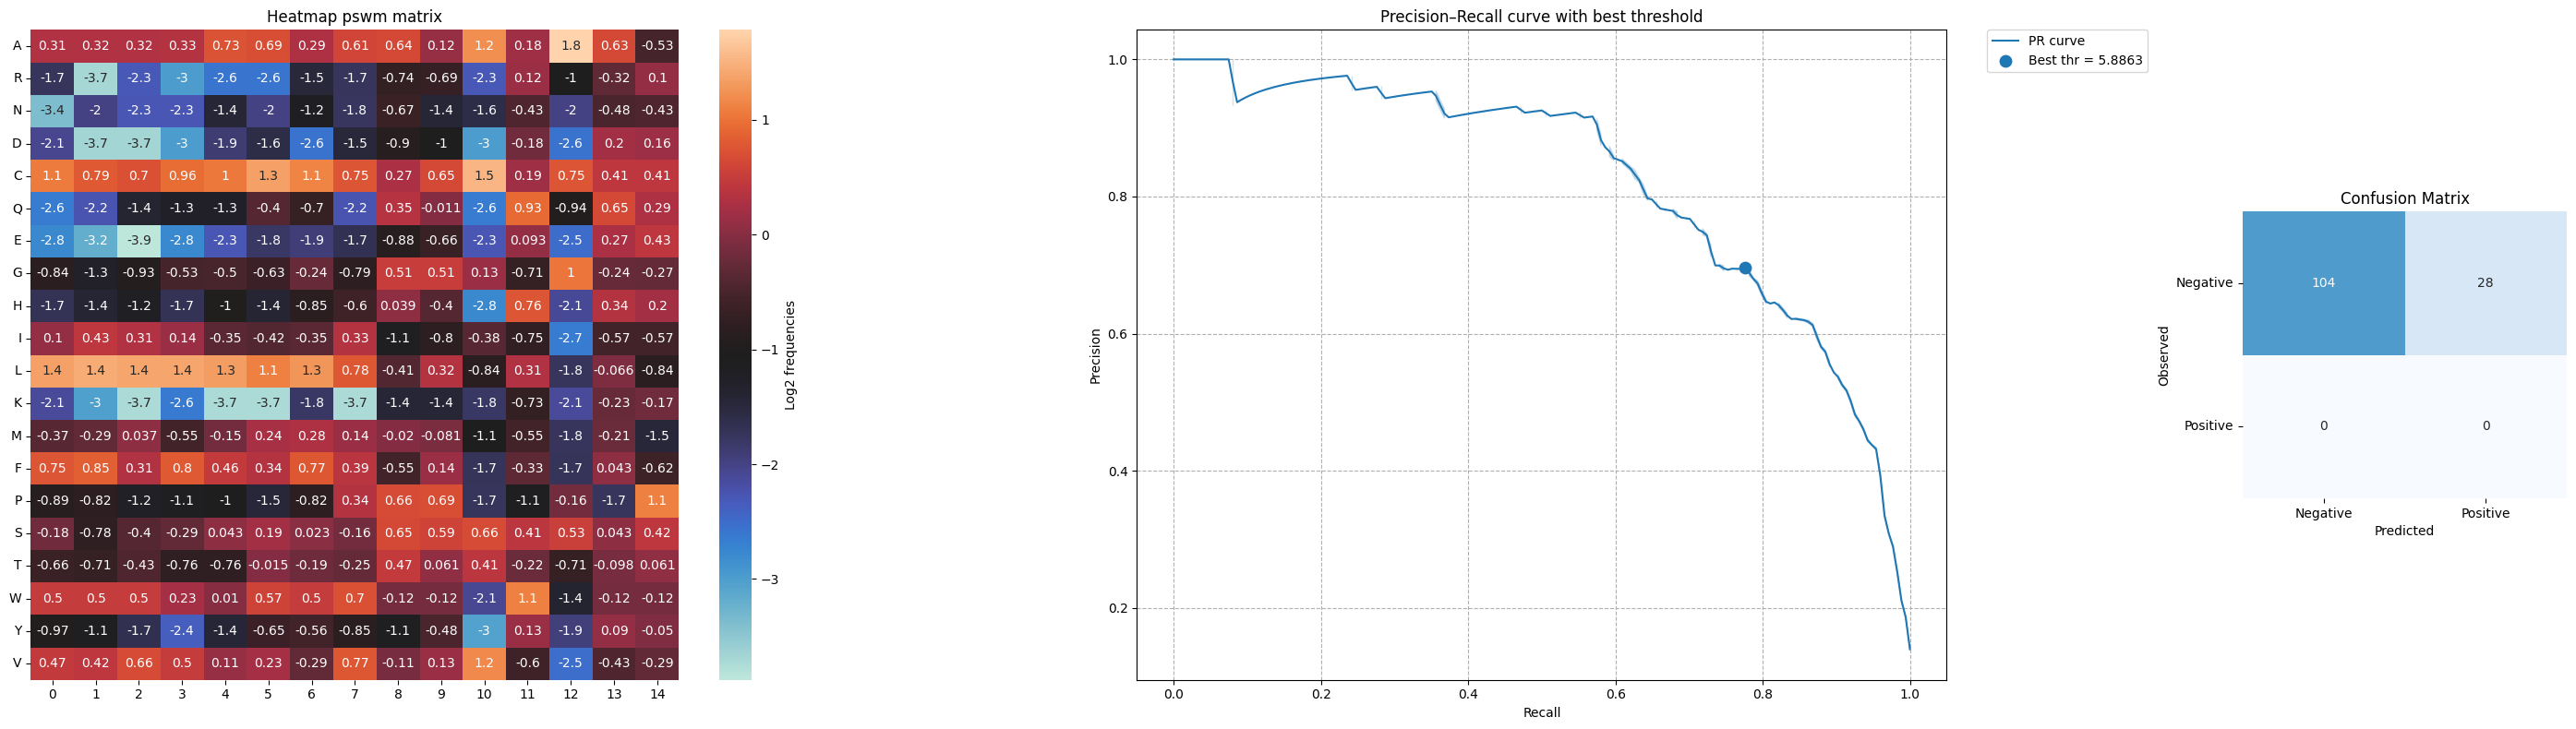

In [19]:
fpr_svm       = len(false_positives) / len(benchmark.query("Class=='Negative'"))
fpr_helix_svm = (len(false_positive.query("HelixDomain==True")) /
                 len(benchmark.query("Class=='Negative' and HelixDomain==True")))

# Von Heijne FPR
fpr_von = (int(confusion_df['Positive']['Negative']) /
           (int(confusion_df['Positive']['Negative']) + int(confusion_df['Negative']['Negative'])))

stats_hd = validation_and_testing_vonheijne.metrics(
    pswm,
    dataset.query("Set=='2'"),
    dataset.query("Set=='Benchmark' and HelixDomain==True"))
confusion_df_hd = pd.DataFrame(stats_hd[4],
                                columns=["Negative", "Positive"],
                                index=["Negative", "Positive"])
fpr_von_hd = (int(confusion_df_hd['Positive']['Negative']) /
              (int(confusion_df_hd['Positive']['Negative']) + int(confusion_df_hd['Negative']['Negative'])))


In [20]:
print("FPR SVM:", fpr_svm)
print("FPR SVM (transmembrane only):", fpr_helix_svm)
print("FPR Von Heijne:", fpr_von)
print("FPR Von Heijne (transmembrane only):", fpr_von_hd)
print(f"\nVon Heijne FPR is {round((fpr_von / fpr_svm) * 100, 1)}% of SVM FPR.")
print(f"On transmembrane proteins Von Heijne FPR is "
      f"{round((fpr_von_hd / fpr_helix_svm) * 100, 1)}% of SVM FPR.")


FPR SVM: 0.01510912143256855
FPR SVM (transmembrane only): 0.045454545454545456
FPR Von Heijne: 0.04756575265808618
FPR Von Heijne (transmembrane only): 0.21212121212121213

Von Heijne FPR is 314.8% of SVM FPR.
On transmembrane proteins Von Heijne FPR is 466.7% of SVM FPR.


## Taxonomic & Amino Acid Analyses

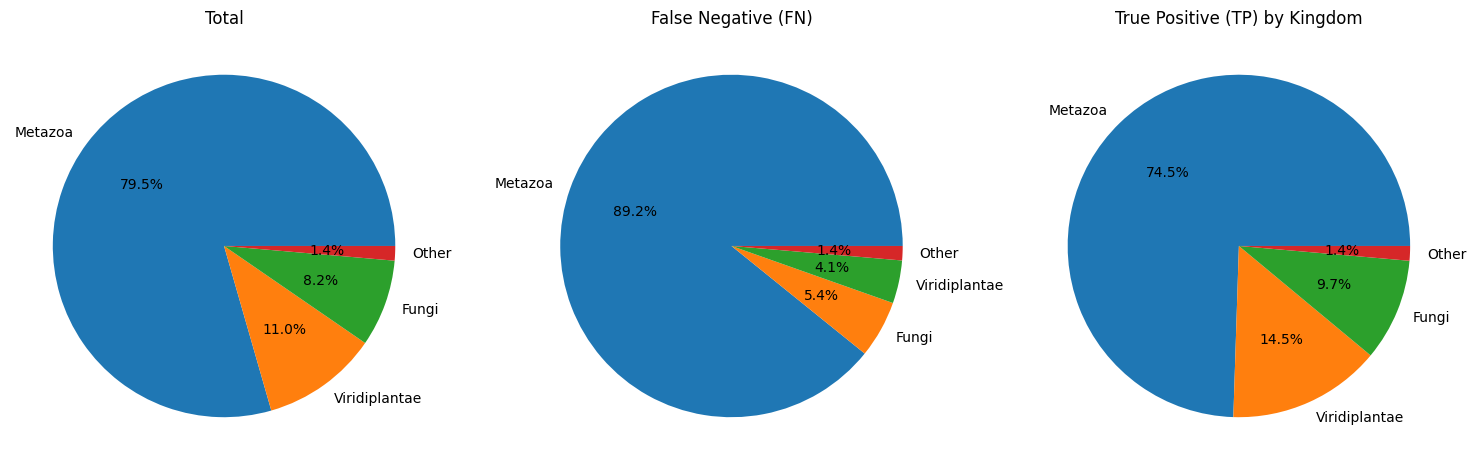

In [21]:
taxa_df     = prediction_dataset.query("Class == 'Positive'").copy()
counts_total = taxa_df['Kingdom'].value_counts()
counts_fn    = taxa_df[taxa_df['Prediction'] == 'FN']['Kingdom'].value_counts()
counts_fp    = taxa_df[taxa_df['Prediction'] == 'TP']['Kingdom'].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].pie(counts_total, labels=counts_total.index, autopct='%1.1f%%')
axes[0].set_title('Total')
axes[1].pie(counts_fn, labels=counts_fn.index, autopct='%1.1f%%')
axes[1].set_title('False Negative (FN)')
axes[2].pie(counts_fp, labels=counts_fp.index, autopct='%1.1f%%')
axes[2].set_title('True Positive (TP) by Kingdom')
plt.tight_layout()
plt.savefig("model_evaluation/Taxa_composition_FP_FN.png", dpi=300)
plt.show()


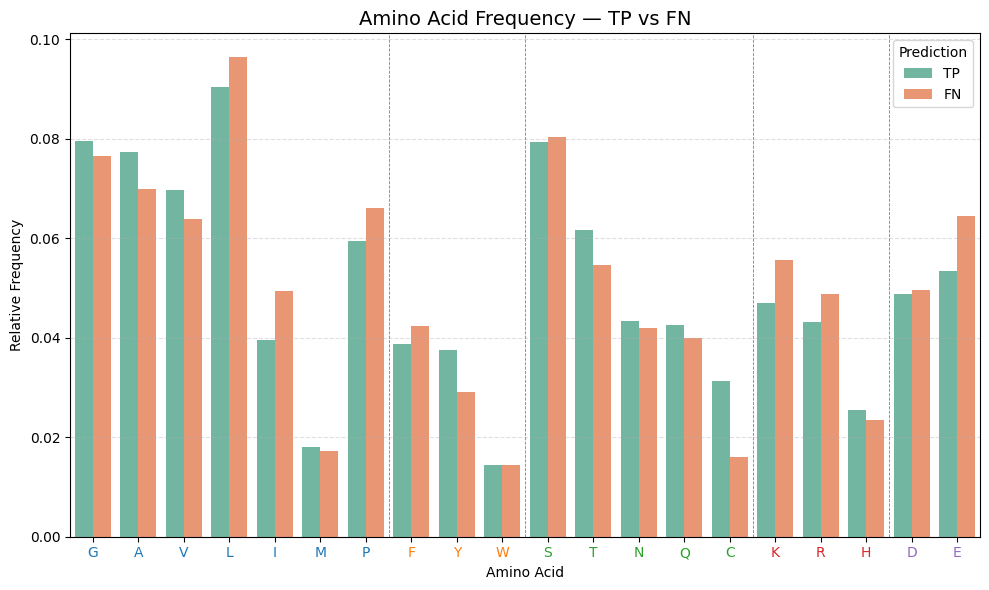

In [22]:
TP_df_sequence = prediction_dataset[prediction_dataset["Prediction"] == "TP"][["Sequence"]].copy()
FN_df_sequence = prediction_dataset[prediction_dataset["Prediction"] == "FN"][["Sequence"]].copy()

def aa_frequency(df):
    all_seq = "".join(df["Sequence"])
    total   = len(all_seq)
    return pd.Series({aa: all_seq.count(aa) / total for aa in set(all_seq)}).sort_index()

TP_freq = aa_frequency(TP_df_sequence)
FN_freq = aa_frequency(FN_df_sequence)

aa_categories = {
    'nonpolar': list("GAVLIMP"), 'aromatic': list("FYW"),
    'polar':    list("STNQC"),   'positive': list("KRH"),
    'negative': list("DE"),
}
aa_order = ['G','A','V','L','I','M','P','F','Y','W','S','T','N','Q','C','K','R','H','D','E']
cat_colors = {'nonpolar':'#1f77b4','aromatic':'#ff7f0e','polar':'#2ca02c',
              'positive':'#d62728','negative':'#9467bd'}
res_to_cat = {aa: cat for cat, aas in aa_categories.items() for aa in aas}

aa_compare = (pd.DataFrame({"TP": TP_freq, "FN": FN_freq}).fillna(0)
              .reset_index()
              .melt(id_vars="index", var_name="Group", value_name="Frequency")
              .rename(columns={"index": "AminoAcid"}))
aa_compare["AminoAcid"] = pd.Categorical(aa_compare["AminoAcid"],
                                          categories=aa_order, ordered=True)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=aa_compare, x="AminoAcid", y="Frequency",
                 hue="Group", order=aa_order, palette="Set2")
ax.set_title("Amino Acid Frequency — TP vs FN", fontsize=14)
ax.set_xlabel("Amino Acid"); ax.set_ylabel("Relative Frequency")
ax.grid(axis='y', linestyle="--", alpha=0.4); ax.legend(title="Prediction")
for label in ax.get_xticklabels():
    cat = res_to_cat.get(label.get_text())
    if cat: label.set_color(cat_colors[cat])
current_cat = None
for i, aa in enumerate(aa_order):
    cat = res_to_cat[aa]
    if current_cat and cat != current_cat:
        ax.axvline(x=i - 0.5, color='gray', linestyle='--', linewidth=0.6)
    current_cat = cat
plt.tight_layout()
plt.show()


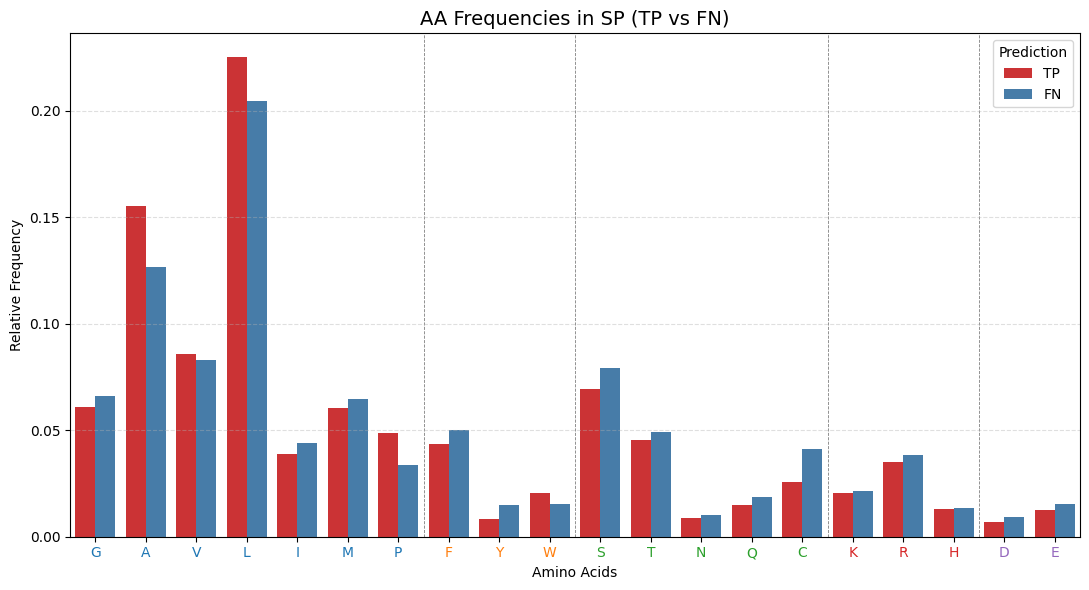

In [23]:
# Signal Peptide AA frequencies
SP_df = prediction_dataset[prediction_dataset["Prediction"].isin(["TP","FN"])][
    ["SPStart","SPEnd","Sequence","Prediction"]].copy()

def SP_aa_frequency(df):
    for index, row in df.iterrows():
        start = int(row["SPStart"]) - 1
        end   = int(row["SPEnd"])
        df.loc[index, "SPSequence"] = row["Sequence"][start:end]
    return df

SP_df = SP_aa_frequency(SP_df)

def SP_frequency(df, label):
    label_df = df[df["Prediction"] == label]
    all_seq  = "".join(label_df["SPSequence"].dropna().astype(str))
    total    = len(all_seq)
    if total == 0: return pd.Series(dtype=float)
    return pd.Series({aa: all_seq.count(aa) / total for aa in sorted(set(all_seq))})

sp_aa_compare = (pd.DataFrame({
    "TP": SP_frequency(SP_df, "TP"),
    "FN": SP_frequency(SP_df, "FN")
}).fillna(0).reset_index()
 .melt(id_vars="index", var_name="Group", value_name="Frequency")
 .rename(columns={"index": "AminoAcid"}))
sp_aa_compare["AminoAcid"] = pd.Categorical(sp_aa_compare["AminoAcid"],
                                              categories=aa_order, ordered=True)

plt.figure(figsize=(11, 6))
ax = sns.barplot(data=sp_aa_compare, x="AminoAcid", y="Frequency",
                 hue="Group", order=aa_order, palette="Set1")
ax.set_title("AA Frequencies in SP (TP vs FN)", fontsize=14)
ax.set_xlabel("Amino Acids"); ax.set_ylabel("Relative Frequency")
ax.grid(axis="y", linestyle="--", alpha=0.4); ax.legend(title="Prediction")
for tick in ax.get_xticklabels():
    cat = res_to_cat.get(tick.get_text())
    if cat: tick.set_color(cat_colors[cat])
current_cat = None
for i, aa in enumerate(aa_order):
    cat = res_to_cat[aa]
    if current_cat and cat != current_cat:
        ax.axvline(x=i - 0.5, color="gray", linestyle="--", linewidth=0.6, zorder=0)
    current_cat = cat
plt.tight_layout()
plt.savefig("model_evaluation/AA_fequencies_3.png", dpi=300)
plt.show()


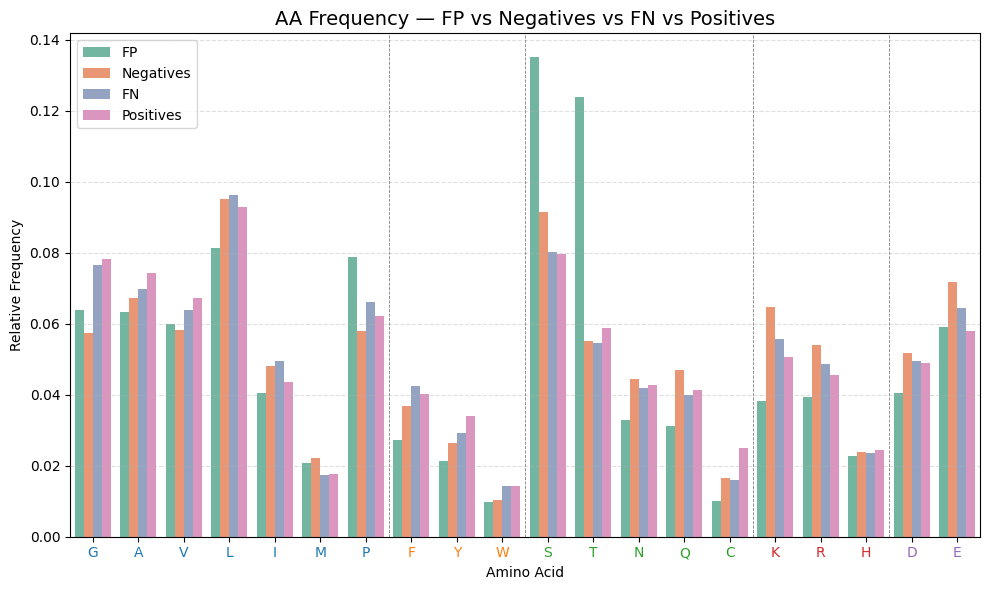

In [24]:
FP_df_sequence = prediction_dataset[prediction_dataset["Prediction"] == "FP"][["Sequence"]].copy()
PP_df_sequence = prediction_dataset[prediction_dataset["Class"] == "Positive"][["Sequence"]].copy()
NN_df_sequence = prediction_dataset[prediction_dataset["Class"] == "Negative"][["Sequence"]].copy()

FP_freq = aa_frequency(FP_df_sequence)
PP_freq = aa_frequency(PP_df_sequence)
NN_freq = aa_frequency(NN_df_sequence)

aa_compare_tot = (pd.DataFrame({
    "FP": FP_freq, "Negatives": NN_freq,
    "FN": FN_freq, "Positives": PP_freq
}).fillna(0).reset_index()
 .melt(id_vars="index", var_name="Group", value_name="Frequency")
 .rename(columns={"index": "AminoAcid"}))
aa_compare_tot["AminoAcid"] = pd.Categorical(aa_compare_tot["AminoAcid"],
                                               categories=aa_order, ordered=True)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=aa_compare_tot, x="AminoAcid", y="Frequency",
                 hue="Group", order=aa_order, palette="Set2")
ax.set_title("AA Frequency — FP vs Negatives vs FN vs Positives", fontsize=14)
ax.set_xlabel("Amino Acid"); ax.set_ylabel("Relative Frequency")
ax.grid(axis='y', linestyle="--", alpha=0.4); ax.legend()
for label in ax.get_xticklabels():
    cat = res_to_cat.get(label.get_text())
    if cat: label.set_color(cat_colors[cat])
current_cat = None
for i, aa in enumerate(aa_order):
    cat = res_to_cat[aa]
    if current_cat and cat != current_cat:
        ax.axvline(x=i - 0.5, color='gray', linestyle='--', linewidth=0.6)
    current_cat = cat
plt.tight_layout()
plt.savefig("model_evaluation/figure9.png", dpi=300)
plt.show()


## Supplementary — Most Informative Feature Distributions

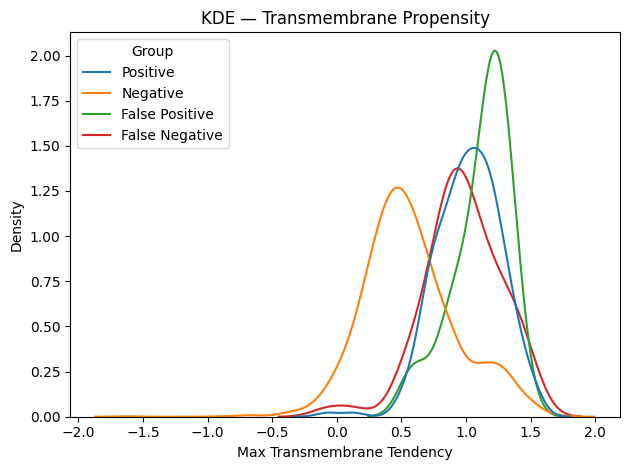

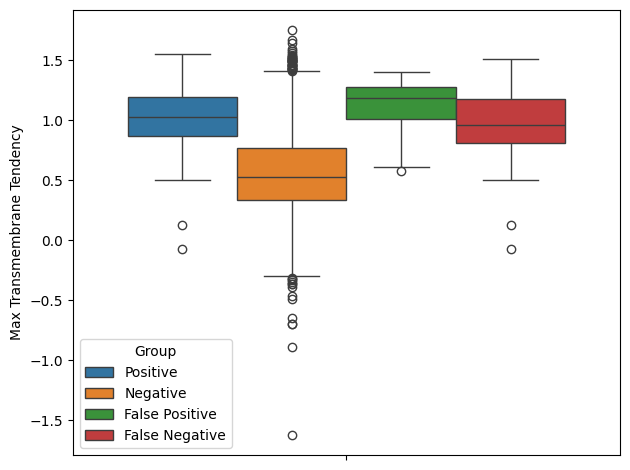

In [25]:
tm_tendency_custom = {
    'A': 0.38,'R':-2.57,'N':-1.62,'D':-3.27,'C':-0.30,
    'Q':-1.84,'E':-2.90,'G':-0.19,'H':-1.44,'I': 1.97,
    'L': 1.82,'K':-3.46,'M': 1.40,'F': 1.98,'P':-1.44,
    'S':-0.53,'T':-0.32,'W': 1.53,'Y': 0.49,'V': 1.40
}
max_tm = scale_function(prediction_dataset["Sequence"], tm_tendency_custom, "max")

pd.options.mode.chained_assignment = None

def make_group_df(base_df, feature_name, values):
    df = base_df.copy(); df[feature_name] = values; return df

tm_df = make_group_df(prediction_dataset, "Max Transmembrane Tendency", max_tm)

def split_groups(df, col):
    pos = df.query("Class == 'Positive'").copy(); pos["Group"] = "Positive"
    neg = df.query("Class == 'Negative'").copy(); neg["Group"] = "Negative"
    fp  = df.query("Prediction == 'FP'").copy();  fp["Group"]  = "False Positive"
    fn  = df.query("Prediction == 'FN'").copy();  fn["Group"]  = "False Negative"
    return pd.concat([pos, neg, fp, fn], axis=0)

tm_ready = split_groups(tm_df, "Max Transmembrane Tendency")

sns.kdeplot(data=tm_ready, x="Max Transmembrane Tendency", hue="Group", common_norm=False)
plt.title("KDE — Transmembrane Propensity"); plt.tight_layout()
plt.savefig("model_evaluation/KDE_TranmembranP.png", dpi=300); plt.show()

sns.boxplot(data=tm_ready, y="Max Transmembrane Tendency", hue="Group")
plt.tight_layout()
plt.savefig("model_evaluation/Boxplot_TRTE.png", dpi=300); plt.show()


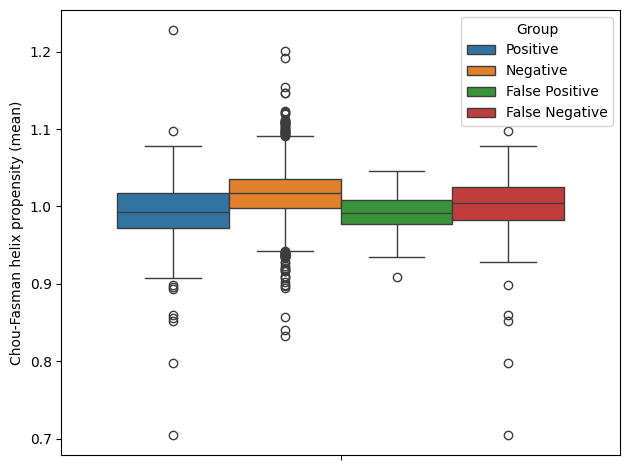

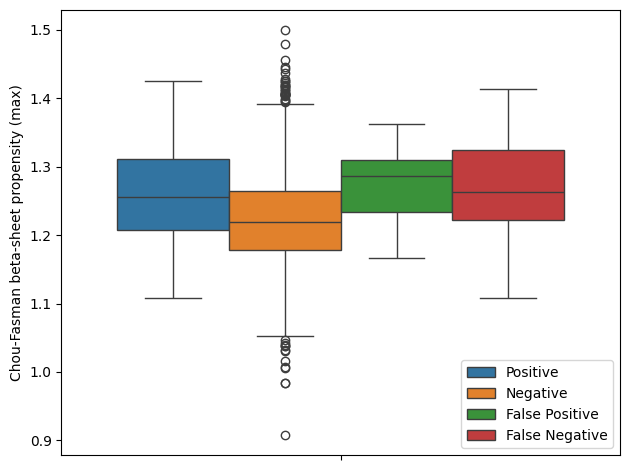

In [26]:
chou_fasman_h = {"A":1.42,"L":1.21,"R":0.98,"K":1.16,"N":0.67,"M":1.45,"D":1.01,
                 "F":1.13,"C":0.70,"P":0.57,"Q":1.11,"S":0.77,"E":1.51,"T":0.83,
                 "G":0.57,"W":1.08,"H":1.00,"Y":0.69,"I":1.08,"V":1.06}
chou_fasman_b = {"A":0.83,"L":1.30,"R":0.93,"K":0.74,"N":0.89,"M":1.05,"D":0.54,
                 "F":1.38,"C":1.19,"P":0.55,"Q":1.10,"S":0.75,"E":0.37,"T":1.19,
                 "G":0.75,"W":1.37,"H":0.87,"Y":1.47,"I":1.60,"V":1.70}

mean_cfh = scale_function(prediction_dataset["Sequence"], chou_fasman_h, "mean")
max_cfb  = scale_function(prediction_dataset["Sequence"], chou_fasman_b, "max")

cf_df = prediction_dataset.copy()
cf_df["Chou-Fasman helix propensity (mean)"]      = mean_cfh
cf_df["Chou-Fasman beta-sheet propensity (max)"]  = max_cfb
cf_ready = split_groups(cf_df, "")

sns.boxplot(data=cf_ready, y="Chou-Fasman helix propensity (mean)", hue="Group")
plt.tight_layout()
plt.savefig("model_evaluation/Boxplot_Chou_Fasman.png", dpi=300); plt.show()

sns.boxplot(data=cf_ready, y="Chou-Fasman beta-sheet propensity (max)", hue="Group")
plt.legend(loc="lower right"); plt.tight_layout()
plt.savefig("model_evaluation/Chou_Fasman_BProp.png", dpi=300); plt.show()


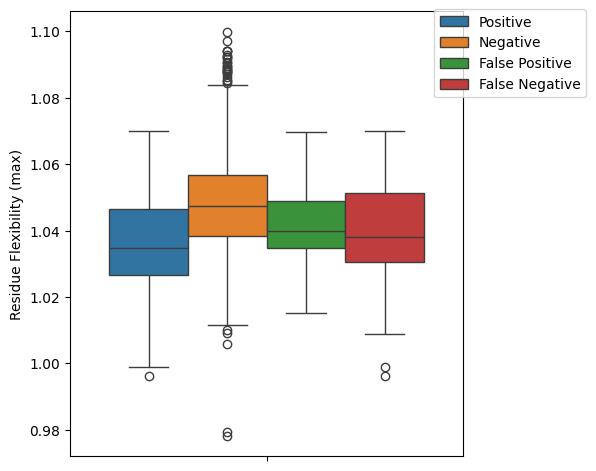

In [27]:
flexibility = scale_function(prediction_dataset["Sequence"], "Flex", "max")
flex_df = prediction_dataset.copy(); flex_df["Residue Flexibility (max)"] = flexibility
flex_ready = split_groups(flex_df, "")

sns.boxplot(data=flex_ready, y="Residue Flexibility (max)", hue="Group")
plt.legend(loc='upper right', bbox_to_anchor=(1.33, 1.02))
plt.tight_layout()
plt.savefig("model_evaluation/Boxplot_ResidueFlex.png", dpi=300); plt.show()


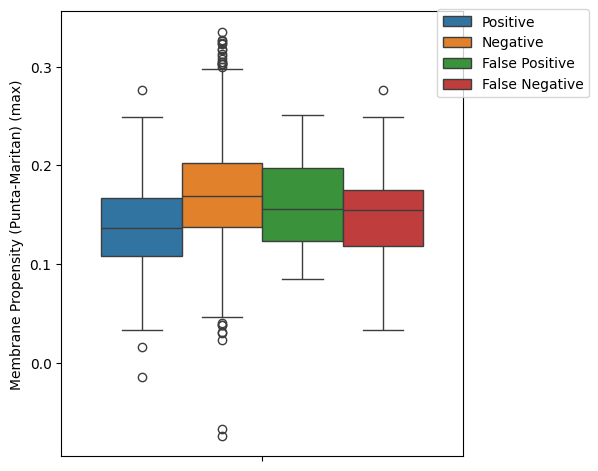

In [28]:
punta_scale = {"A":-0.17,"L":-0.28,"R":0.37,"K":0.32,"N":0.18,"M":-0.26,"D":0.37,
               "F":-0.41,"C":-0.06,"P":0.13,"Q":0.26,"S":0.05,"E":0.15,"T":0.02,
               "G":0.01,"W":-0.15,"H":-0.02,"Y":-0.09,"I":-0.28,"V":-0.17}
punta = scale_function(prediction_dataset["Sequence"], punta_scale, "max")
punta_df = prediction_dataset.copy()
punta_df["Membrane Propensity (Punta-Maritan) (max)"] = punta
punta_ready = split_groups(punta_df, "")

sns.boxplot(data=punta_ready, y="Membrane Propensity (Punta-Maritan) (max)", hue="Group")
plt.legend(loc='upper right', bbox_to_anchor=(1.33, 1.02))
plt.tight_layout()
plt.savefig("model_evaluation/Boxplot_PuntaMaritan.png", dpi=300); plt.show()


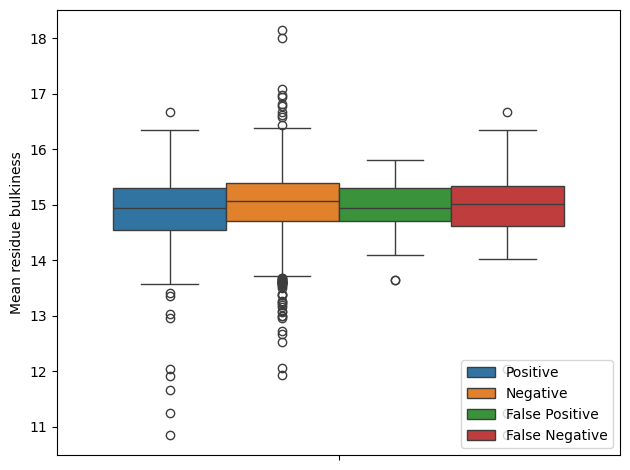

In [29]:
bulkiness_scale = {"A":11.50,"R":14.28,"N":12.82,"D":11.68,"C":13.46,"Q":14.45,
                   "E":13.57,"G":3.40,"H":13.69,"I":21.40,"L":21.40,"K":15.71,
                   "M":16.25,"F":19.80,"P":17.43,"S":9.47,"T":15.77,"W":21.67,
                   "Y":18.03,"V":21.57}
bulk = scale_function(prediction_dataset["Sequence"], bulkiness_scale, "mean")
bulk_df = prediction_dataset.copy(); bulk_df["Mean residue bulkiness"] = bulk
bulk_ready = split_groups(bulk_df, "")

sns.boxplot(data=bulk_ready, y="Mean residue bulkiness", hue="Group")
plt.legend(loc='lower right'); plt.tight_layout()
plt.savefig("model_evaluation/boxplot_Bulkiness.png", dpi=300); plt.show()


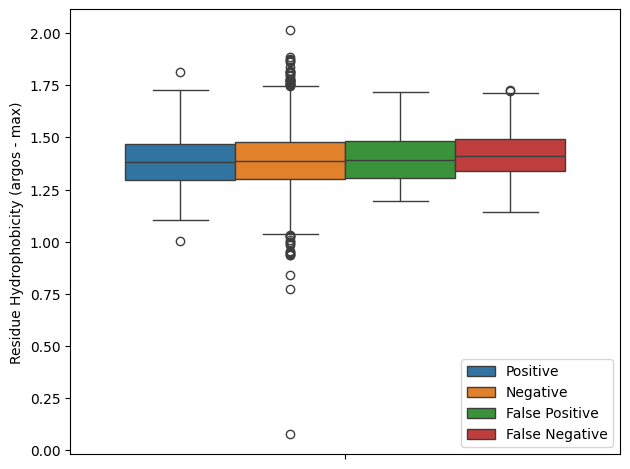

In [30]:
argos_max = scale_function(prediction_dataset["Sequence"], "ag", "max")
argos_df  = prediction_dataset.copy()
argos_df["Residue Hydrophobicity (argos - max)"] = argos_max
argos_ready = split_groups(argos_df, "")

sns.boxplot(data=argos_ready, y="Residue Hydrophobicity (argos - max)", hue="Group")
plt.legend(loc='lower right'); plt.tight_layout()
plt.savefig("model_evaluation/Boxplot_ArgosMax.png", dpi=300); plt.show()


## Sequence Logos

Logos — metric: information


<Figure size 600x1400 with 0 Axes>

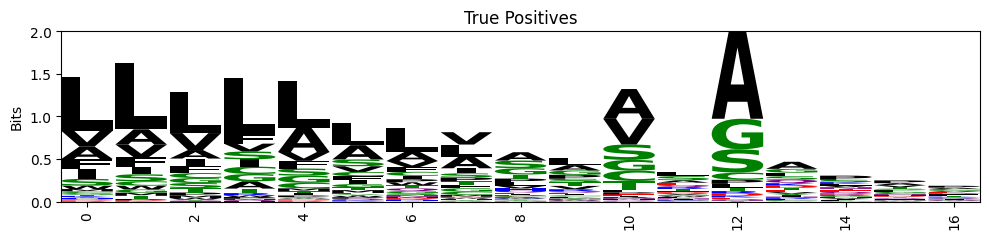

<Figure size 600x1400 with 0 Axes>

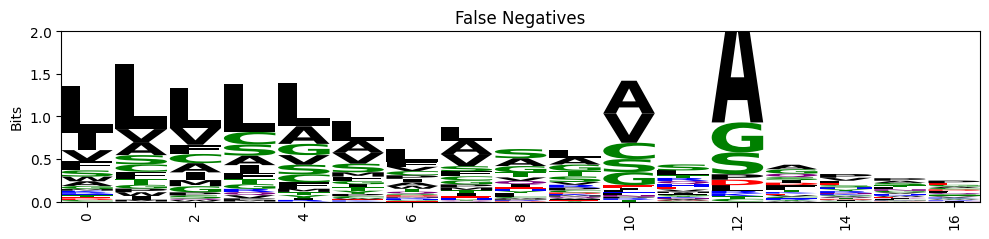

<Figure size 600x1400 with 0 Axes>

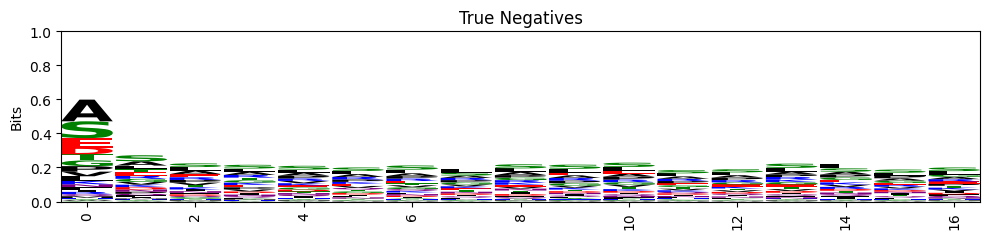

<Figure size 600x1400 with 0 Axes>

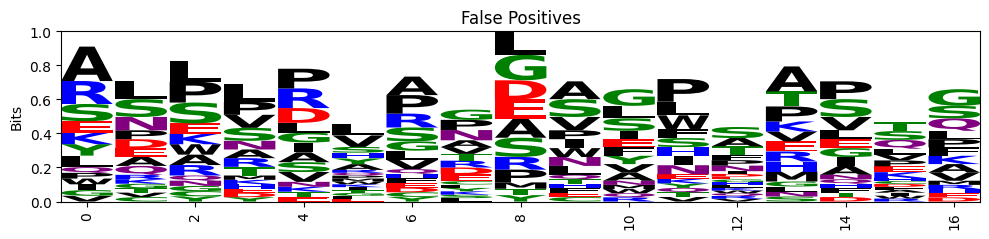

Logos — metric: probability


<Figure size 600x1400 with 0 Axes>

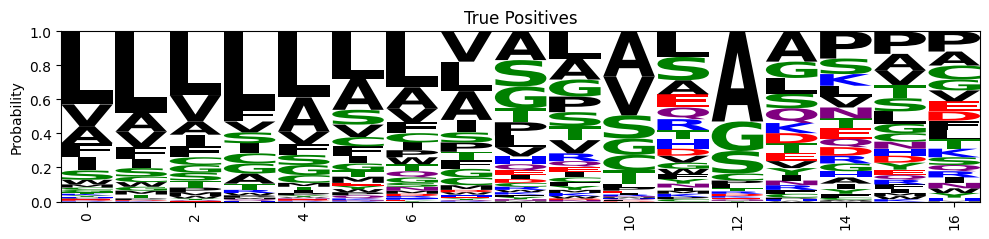

<Figure size 600x1400 with 0 Axes>

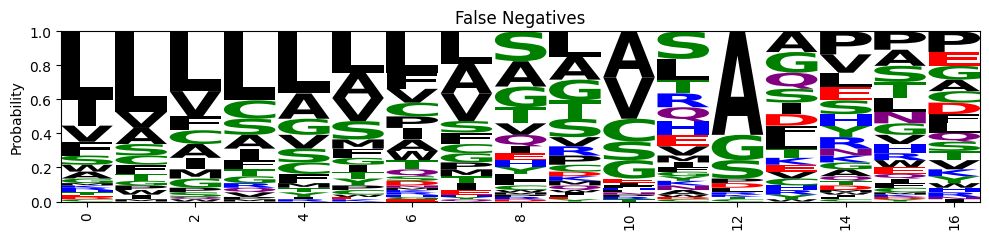

<Figure size 600x1400 with 0 Axes>

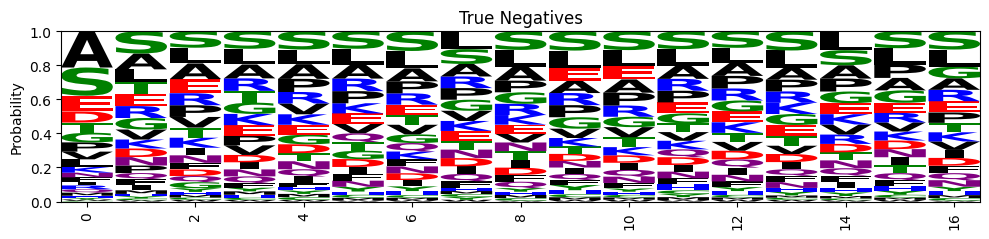

<Figure size 600x1400 with 0 Axes>

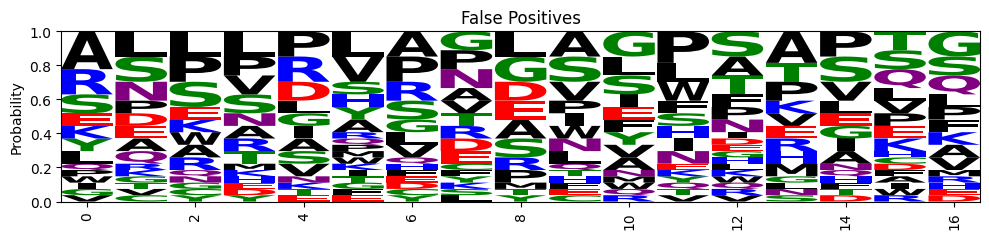

In [31]:
import logomaker as lm

logo_pos_seqs, logo_neg_seqs, logo_fn_seqs, logo_fp_seqs = [], [], [], []

logo_neg = prediction_dataset.query("Class == 'Negative'")
for _, row in logo_neg.iterrows():
    seq = row["Sequence"]
    logo_neg_seqs.append(seq[1:18])
    if row["Prediction"] == "FP":
        logo_fp_seqs.append(seq[1:18])

logo_pos = prediction_dataset.query("Class == 'Positive'")
for _, row in logo_pos.iterrows():
    seq = row["Sequence"]
    cp  = int(row["SPEnd"])
    logo_pos_seqs.append(seq[cp - 13: cp + 4])
    if row["Prediction"] == "FN":
        logo_fn_seqs.append(seq[cp - 13: cp + 4])

logo_fullseqs = [logo_pos_seqs, logo_fn_seqs, logo_neg_seqs, logo_fp_seqs]
labels        = ["True Positives", "False Negatives", "True Negatives", "False Positives"]

for metric, fname_prefix in [("information", "figure12A"), ("probability", "Sequence_Logo")]:
    print(f"Logos — metric: {metric}")
    for count, (seqs, label) in enumerate(zip(logo_fullseqs, labels), 1):
        logo_mat = lm.alignment_to_matrix(sequences=seqs, to_type=metric,
                                          characters_to_ignore='.-X', pseudocount=0)
        plt.figure(figsize=(6, 14))
        lm.Logo(logo_mat, shade_below=.5, fade_below=.5, color_scheme="chemistry")
        plt.xticks(rotation=90)
        plt.ylabel("Bits" if metric == "information" else "Probability")
        if label in ["True Negatives", "False Positives"]:
            plt.ylim(0, 1.0)
        elif metric == "information":
            plt.ylim(0, 2.0)
        plt.title(label); plt.tight_layout()
        plt.savefig(f"model_evaluation/{fname_prefix}-{count}.png", dpi=300)
        plt.show()


In [32]:
# Viridiplantae / Arabidopsis FPR
plant_df = prediction_dataset.query("Kingdom == 'Viridiplantae'")
print("FPR in plant entries:",
      plant_df.query("Prediction == 'FP'").shape[0] /
      plant_df.query("Class == 'Negative'").shape[0])
print("FPR overall:", fpr_svm)
print("\nTotal plant entries:", plant_df.shape[0])
print("Arabidopsis thaliana entries:",
      plant_df.query("OrganismName == 'Arabidopsis thaliana'").shape[0])

fpr_ara = (plant_df.query("OrganismName == 'Arabidopsis thaliana' and Prediction == 'FP'").shape[0] /
           plant_df.query("OrganismName == 'Arabidopsis thaliana' and Class == 'Negative'").shape[0])
fpr_not = (plant_df.query("OrganismName != 'Arabidopsis thaliana' and Prediction == 'FP'").shape[0] /
           plant_df.query("OrganismName != 'Arabidopsis thaliana' and Class == 'Negative'").shape[0])
print("FPR Arabidopsis:", fpr_ara)
print("FPR all other plants:", fpr_not)


FPR in plant entries: 0.012698412698412698
FPR overall: 0.01510912143256855

Total plant entries: 339
Arabidopsis thaliana entries: 243
FPR Arabidopsis: 0.008298755186721992
FPR all other plants: 0.02702702702702703
